**Problem 2: Predicting Chlorophyll-A (Green color) Levels in Laguna Lake**

**This MEX2 was worked on in partnership with Ethan Capcuchino, in the same class.**

Go to https://github.com/kspilario/predict_chlorophyll/blob/main/chlor.csv

Download this Chlorophyll-A (Chl-a) dataset collected from Laguna Lake in 2023. The dataset contains Chl-a level as outputs (1st column) and nutrient levels as inputs (3rd to 6th columns). All other columns are irrelevant for this problem.

Your goal is to predict the Chl-a levels in Laguna Lake. This is important because Metro Manila gets drinking water from treating Laguna Lake water. If the Chl-a level is too high, water shortages may occur. Answer the following:

a. [10 pts] First, remove the rows with missing data via Pandas. Visualize the data as a pair plot.

b. [20 pts] Split the data into 70% training and 30% testing at random. Make a pipeline using Standard Scaler and Gaussian Process Regressor. Train the model using the training set, then report the RMSE (root mean squared error) on the Test Set. You can fine-tune your own model by changing the kernel function, kernel parameter, and epsilon.

c. [20 pts] Do the same as (b) but now using Standard Scaler + Kernel Ridge Regression (KRR). You can fine-tune your KRR by changing the kernel function, kernel parameter, and regularization (alpha). Compare the results of GPR versus KRR in terms of accuracy.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**a. [10 pts] First, remove the rows with missing data via Pandas. Visualize the data as a pair plot.**

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/kspilario/predict_chlorophyll/main/chlor.csv")

# We only need columns 1,3,4,5,6
df = df.iloc[:, [0, 2, 3, 4, 5]]
df.columns = ['Chl_a', 'NO2', 'NO3', 'NH4', 'PO4']

# Remove NaN
df = df.dropna()

print("First 5 records:\n", df.head())

First 5 records:
    Chl_a      NO2       NO3        NH4        PO4
0   6.66  0.21830  0.522735  31.784807  15.317651
1   6.45  0.21830  0.522735  31.784807  15.317651
2   6.27  0.21830  0.522735  31.784807  15.317651
3   6.13  0.21495  0.527931  30.446107  14.834307
4   6.10  0.21495  0.527931  30.446107  14.834307


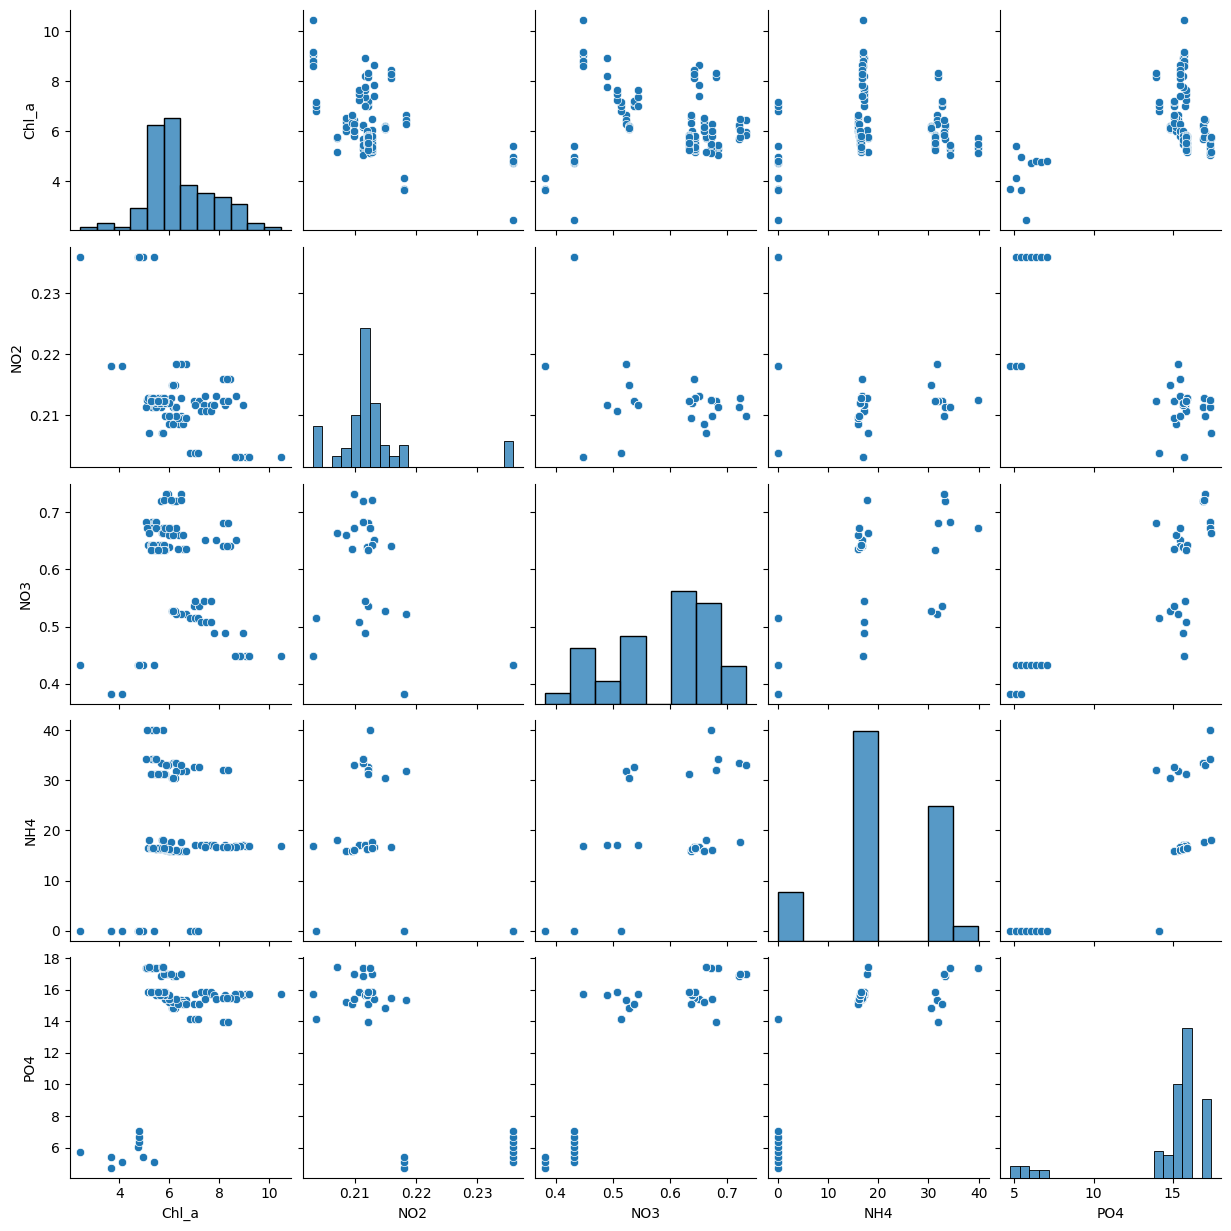

In [3]:
sns.pairplot(df)
plt.show()

**b. [20 pts] Split the data into 70% training and 30% testing at random. Make a pipeline using Standard Scaler and Gaussian Process Regressor. Train the model using the training set, then report the RMSE (root mean squared error) on the Test Set. You can fine-tune your own model by changing the kernel function, kernel parameter, and epsilon.**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error
from sklearn.kernel_ridge import KernelRidge

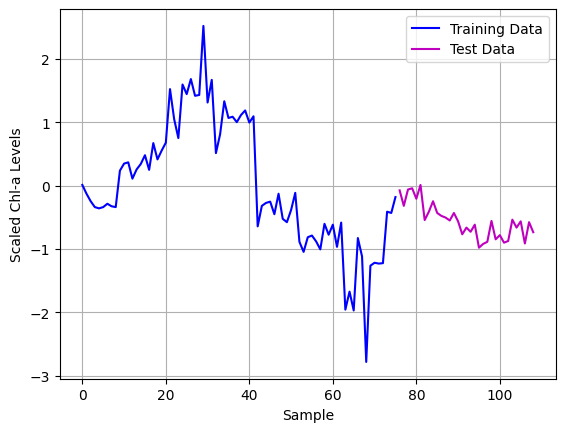

(76, 1)
(76, 1)
(33, 1)
(33, 1)


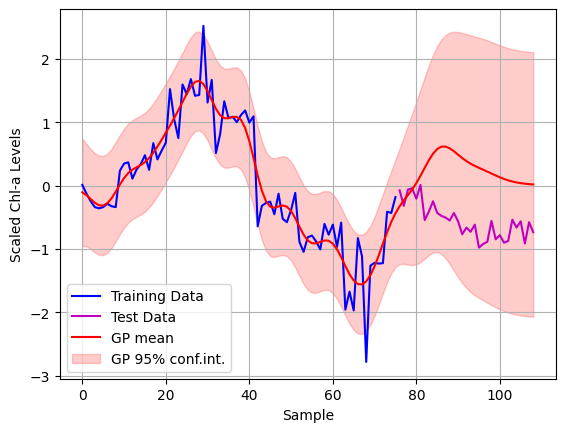

Optimized kernel:
RBF(length_scale=10.6) * ExpSineSquared(length_scale=6.05, periodicity=12.2) + WhiteKernel(noise_level=0.135)
Training MSE: 0.11118509534203722
Testing MSE: 0.7582582091542581


In [ ]:
train_size = int(len(df) * 0.7)
X_train = np.arange(0,train_size).reshape(-1,1)
X_test = np.arange(train_size,len(df)).reshape(-1,1)
# y_train, y_test = df[0:train_size], df[train_size:] -> we don't need to use all
y_train = df['Chl_a'][0:train_size].values.reshape(-1,1)
y_test = df['Chl_a'][train_size:].values.reshape(-1,1)

# In our pipeline, use StandardScaler
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

plt.plot(np.arange(0,len(y_train_scaled)), y_train_scaled,'b')
plt.plot(np.arange(len(y_train_scaled),len(df)), y_test_scaled, 'm')
plt.grid()
plt.legend(('Training Data','Test Data'))
plt.ylabel('Scaled Chl-a Levels')
plt.xlabel('Sample')
plt.show()
print(X_train.shape)
print(y_train_scaled.shape)
print(X_test.shape)
print(y_test_scaled.shape)

# Kernel compistion and fit using GPR
SExPER_kernel = (RBF(length_scale=1.5) * ExpSineSquared(length_scale=0.5, periodicity=12))
noise_kernel = WhiteKernel(noise_level=0.01)
overall_kernel = (SExPER_kernel + noise_kernel)

y_mean = y_train_scaled.mean()

# EXPERIMENTING WITH FINETUNING THE GPR

# (0) Original GPR made & resulting Training and Testing MSE
'''
GPR = GaussianProcessRegressor(kernel=overall_kernel,
                               normalize_y=False,
                               n_restarts_optimizer=10,
                               random_state=0)
'''
# Training MSE: 0.11118509534203827
# Testing MSE: 0.7582582091542552

# Finetuning
# Note: By default, alpha is =1e-10 = 0.0000000001

# (1) Setting kernel=SExPER_kernel --> No noise kernel
'''
GPR = GaussianProcessRegressor(kernel=SExPER_kernel,
                               normalize_y=False,
                               n_restarts_optimizer=10,
                               random_state=0)
'''
# Training MSE: 6.361836746316193e-20
# Testing MSE: 0.4518572362789893
# Observation: Reduced both the training and testing MSE

# (2) Setting kernel=SExPER_kernel and n_restarts_optimizer=0 --> No noise kernel and set n_restarts_optimizer to 0
'''
GPR = GaussianProcessRegressor(kernel=SExPER_kernel,
                               normalize_y=False,
                               n_restarts_optimizer=0,
                               random_state=0)
'''
# Training MSE: 6.361836746316193e-20
# Testing MSE: 0.4518572362789893
# Observation: Changing n_restarts_optimizer from 10 to 0 did not lead to any significant changes

# (3) Setting kernel=SExPER_kernel, n_restarts_optimizer=0, and alpha=0 --> In addition to (1), (2), set alpha = 0
'''
GPR = GaussianProcessRegressor(kernel=SExPER_kernel,
                               alpha=0,
                               normalize_y=False,
                               n_restarts_optimizer=0,
                               random_state=0)
'''
# Training MSE: 9.223212774975825e-32
# Testing MSE: 0.38479244640377186
# Observation: Change alpha from its default of 0.0000000001 to 0, reduces both MSEs further

# No finetuning for now (will report findings in discussion anyways)
GPR = GaussianProcessRegressor(kernel=overall_kernel,
                               normalize_y=False,
                               n_restarts_optimizer=10,
                               random_state=0)

GPR.fit(X_train, y_train_scaled - y_mean)

X = np.arange(0,len(df)).reshape(-1,1)
mean_y_pred, std_y_pred = GPR.predict(X, return_std=True)
mean_y_pred += y_mean
plt.plot(np.arange(0,len(y_train_scaled)), y_train_scaled,'b',label='Training Data')
plt.plot(np.arange(len(y_train_scaled),len(df)), y_test_scaled,'m',label='Test Data')
plt.plot(X,mean_y_pred,'r',label='GP mean')
plt.fill_between(
    X.ravel(),
    mean_y_pred - 1.96*std_y_pred,
    mean_y_pred + 1.96*std_y_pred,
    color='r',
    alpha=0.2,
    label='GP 95% conf.int.'
)
plt.ylabel('Scaled Chl-a Levels')
plt.xlabel('Sample')
plt.grid()
plt.legend()
plt.show()
print('Optimized kernel:')
print(GPR.kernel_)
train_mse = mean_squared_error(y_train_scaled, mean_y_pred[:train_size])
test_mse = mean_squared_error(y_test_scaled, mean_y_pred[train_size:len(df)])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

**c. [20 pts] Do the same as (b) but now using Standard Scaler + Kernel Ridge Regression (KRR). You can fine-tune your KRR by changing the kernel function, kernel parameter, and regularization (alpha). Compare the results of GPR versus KRR in terms of accuracy.**

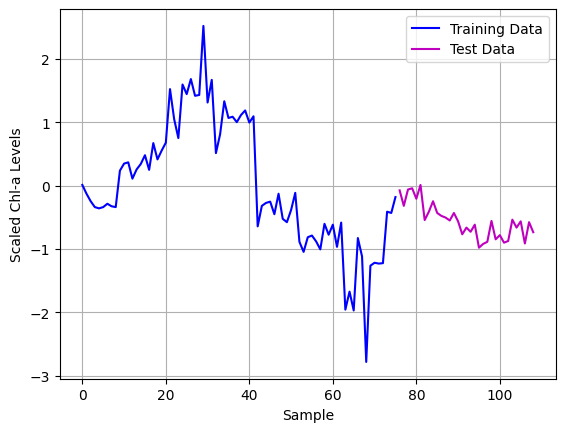

(76, 1)
(76, 1)
(33, 1)
(33, 1)


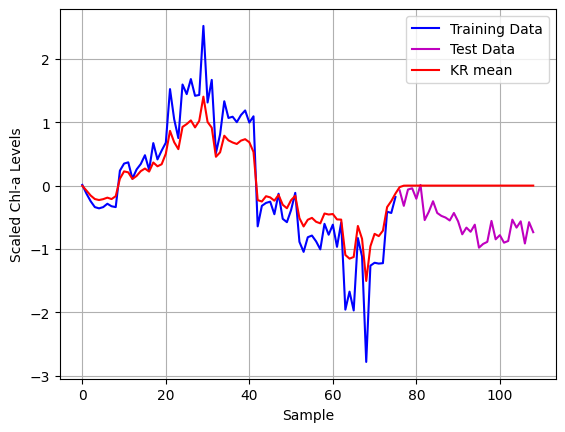

Kernel used:
rbf
Training MSE: 0.1540000588682635
Testing MSE: 0.3837005424273735


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

train_size = int(len(df) * 0.7)
X_train = np.arange(0, train_size).reshape(-1, 1)
X_test = np.arange(train_size, len(df)).reshape(-1, 1)
y_train = df['Chl_a'][0:train_size].values.reshape(-1, 1)
y_test = df['Chl_a'][train_size:].values.reshape(-1, 1)

scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

plt.plot(np.arange(0, len(y_train_scaled)), y_train_scaled, 'b')
plt.plot(np.arange(len(y_train_scaled), len(df)), y_test_scaled, 'm')
plt.grid()
plt.legend(('Training Data', 'Test Data'))
plt.ylabel('Scaled Chl-a Levels')
plt.xlabel('Sample')
plt.show()

print(X_train.shape)
print(y_train_scaled.shape)
print(X_test.shape)
print(y_test_scaled.shape)

y_mean = y_train_scaled.mean()

# CHANGE: Kernel Ridge Regression (KRR) instead of GPR
# NOTE: uncomment 'KRR = ' lines to select what KRR parameters to use

# (0) Original
KRR = KernelRidge(kernel='rbf', gamma=None)
# Kernel: rbf
# Training MSE: 0.1540000588682635
# Testing MSE: 0.3837005424273735

# Finetuning

# (1) Changing alpha to alpha=0.0
# KRR = KernelRidge(kernel='rbf', alpha=0.0, gamma=None)
# Kernel: rbf
# Training MSE: 2.676286346753813e-32
# Testing MSE: 0.38375472781754577
# Observation: Reduced training MSE, but no significant change in the testing MSE

# (2) Changing kernel to laplacian
# KRR = KernelRidge(kernel='laplacian', gamma=None)
# Kernel: laplacian
# Training MSE: 0.12891504129580564
# Testing MSE: 0.3832560863613909
# Observation: From (0), slightly shows lower MSE than rbf for both train and test

# (3) Changing kernel to linear
# KRR = KernelRidge(kernel='linear', gamma=None)
# Kernel: linear
# Training MSE: 0.9241724311368179
# Testing MSE: 0.05311731458838531
# Observation: From (0), shows much lower testing MSE, but very high training MSE

# (4) Changing kernel to sigmoid
# KRR = KernelRidge(kernel='sigmoid', gamma=None)
# Kernel: sigmoid
# Training MSE: 1.0000267433019376
# Testing MSE: 0.3836529260146427
# Observation: From (0), shows almost the same testing MSE, but very high training MSE

# (5) Changing kernel to laplacian, and alpha=0.0
# KRR = KernelRidge(kernel='laplacian', alpha=0.0, gamma=None)
# Kernel: laplacian
# Training MSE: 2.965049132494505e-32
# Testing MSE: 0.3831250308388953
# Observation: Is similar in terms of results as the rbf when alpha=0.0

KRR.fit(X_train, y_train_scaled - y_mean)

# CHANGE: no return_std with KRR
X = np.arange(0,len(df)).reshape(-1,1)
mean_y_pred = KRR.predict(X)
mean_y_pred += y_mean
plt.plot(np.arange(0, len(y_train_scaled)), y_train_scaled, 'b', label='Training Data')
plt.plot(np.arange(len(y_train_scaled), len(df)), y_test_scaled, 'm', label='Test Data')
plt.plot(X, mean_y_pred, 'r', label='KR mean')
plt.ylabel('Scaled Chl-a Levels')
plt.xlabel('Sample')
plt.grid()
plt.legend()
plt.show()

# Print kernel (KRR stores string, unlike GPR kernel objects)
print('Kernel used:')
print(KRR.kernel)

# Compute MSE
train_mse = mean_squared_error(y_train_scaled, mean_y_pred[:train_size])
test_mse = mean_squared_error(y_test_scaled, mean_y_pred[train_size:len(df)])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

# **Answers/Discussion:**

# **Original**

**[Original] Gaussian Process Regressor (GPR) - no finetuning**

Where:
* overall_kernel = SExPER_kernel + noise_kernel
* alpha is default = 1e-10 = 0.0000000001
* n_restarts_optimizer = 10

MSE:
*   Training MSE: 0.11118509534203827
*   Testing MSE: 0.7582582091542552

**[Original] Kernel Ridge Regression (KRR) - no finetuning**

Where:
* Kernel: rbf (Radial basis function kernel)
* alpha is default

MSE:
*   Training MSE: 0.1540000588682635
*   Testing MSE: 0.3837005424273735

A lower MSE (Mean Squared Error) suggests **better model accuracy**; hence, the results show that, comapring the baseline (not finetuned) pipelines, the StandardScaler + KRR has higher testing accuracy than the pipeline with GPR, although GPR has a slight edge in terms of training accuracy. The difference between the testing MSE for the GPR vs the KRR is quite significant where the GPR is around 0.7582 and the KRR is around 0.3837, much lower.

# **Finetuning**

**GPR**

(1) Setting overall_kernel = SExPER_kernel --> **No noise kernel**
* Training MSE: 6.361836746316193e-20
* Testing MSE: 0.4518572362789893
* **Observation: Reduced both the training and testing MSE**

(2) Setting overall_kernel = SExPER_kernel --> **No noise kernel** and **n_restarts_optimizer = 0**
* Training MSE: 6.361836746316193e-20
* Testing MSE: 0.4518572362789893
* **Observation: Changing n_restarts_optimizer from 10 to 0 did not lead to any significant changes**

(3) Setting kernel=SExPER_kernel, n_restarts_optimizer=0, and alpha=0 --> **In addition to (1), (2), set alpha = 0**
* Training MSE: 9.223212774975825e-32
* Testing MSE: 0.38479244640377186
* **Observation: Changing alpha from its default of 0.0000000001 to 0, reduces both MSEs further**

**Hence, we are able to see how removing the noise kernel, and reducing the alpha even further (to zero) leads to reduced Training and Testing MSE for the Gaussian Process Regressor (GPR).**

**KRR**

(1) Kernel: rbf --> **Changing alpha from default to alpha=0.0**
* Training MSE: 2.676286346753813e-32
* Testing MSE: 0.38375472781754577
* **Observation: Reduced training MSE, but no significant change in the testing MSE**

Note: From (2) to (4), we went back to alpha being set to default, and instead we want to look at the change between different kernels

(2) Kernel: laplacian
* Training MSE: 0.12891504129580564
* Testing MSE: 0.3832560863613909
* **Observation: From (0), slightly shows lower MSE than rbf for both train and test**

(3) Kernel: linear
* Training MSE: 0.9241724311368179
* Testing MSE: 0.05311731458838531
* **Observation: From (0), shows much lower testing MSE, but very high training MSE**

(4) Kernel: sigmoid
* Training MSE: 1.0000267433019376
* Testing MSE: 0.3836529260146427
* **Observation: From (0), shows almost the same testing MSE, but very high training MSE**

(5) Kernel: laplacian --> **Changing alpha from default to alpha=0.0**
* Training MSE: 2.965049132494505e-32
* Testing MSE: 0.3831250308388953
* **Observation: Is similar in terms of results as the rbf when alpha=0.0**

**Hence, we are able to see how using rbf or laplacian kernels (as opposed to linear and sigmoid), and reducing the alpha even further (to zero) leads to reduced Training and Testing MSE for the Kernel Ridge Regression (KRR).**

# **Conclusion**

**To go over the best found results through finetuning, the GPR can boast around 9.223212774975825e-32 Training MSE and 0.38479244640377186 Testing MSE by removing the noise kernel and setting alpha to zero, while the KRR can boast around 2.676286346753813e-32 Training MSE and 0.38375472781754577 Testing MSE, by setting the alpha to zero (for rbf) and we can achieve comparable results with laplacian kernel when alpha is zero. Generally we find that using KRR leads to lower MSE, however through some finetuning we are able to attain relatively close Testing MSEs with the GPR through changing alpha and the kernels. Finally, through this MEX, we were able to successfully predict the Chl-a levels in Laguna Lake, with the use of StandardScaler in combination with either a Gaussian Process Regressor (GPR) or a Kernel Ridge Regression (KRR) in our pipeline.**